In [1]:
import os
import sys
base_directory = os.path.dirname(os.path.abspath(""))
sys.path.append(base_directory)

import matplotlib.pyplot as plt

from src.build_database_table import search_pubmed
from src.utils import drop_one_analysis
from tests.conftest import _paper_ground_truth

In [2]:
def make_bar_plot(results):
    labels = [r[0] for r in results]
    values = [r[1] for r in results]

    plt.figure(figsize=(10, 8))
    plt.barh(labels, values)  # horizontal is much better for long labels
    plt.xlabel("Number of Results")
    plt.title("Drop-One Analysis of PubMed Query")

    plt.tight_layout()
    plt.show()

# Let's practice analyzing a query.

In [ ]:
PUBMED_QUERY = """
("Databases, Factual"[MeSH] OR "Database Management Systems"[MeSH] OR dataset[ti] OR database[ti] OR "data collection"[ti] OR "information repository"[ti] OR benchmark[ti] OR "challenge data"[ti] OR "data commons"[ti] OR "data repository"[ti] OR "data sharing"[ti])
AND ("Radiology"[MeSH] OR "Radiography"[MeSH] OR "Radiology Information Systems"[MeSH] OR radiology[tiab] OR radiograph[tiab] OR "Diagnostic Imaging"[tiab] OR "Medical Image"[tiab] OR "Medical Imaging"[tiab] OR "Biomedical Image"[tiab] OR "Biomedical Imaging"[tiab] OR XR[tiab] OR CT[tiab] OR MRI[tiab] OR PET[tiab] OR SPECT[tiab] OR "X-ray"[tiab] OR "Computed Tomography"[tiab] OR "Magnetic Resonance"[tiab] OR Ultrasound[tiab] OR "Positron Emission Tomography"[tiab] OR "Single Photon Emission Computed Tomography"[tiab])
"""

In [4]:
results = drop_one_analysis(PUBMED_QUERY)
results

[('BASE', 12889),
 ('DROP LEFT: "Databases, Factual"[MeSH]', 4224),
 ('DROP LEFT: "Database Management Systems"[MeSH]', 12245),
 ('DROP LEFT: dataset[ti]', 11797),
 ('DROP LEFT: database[ti]', 12095),
 ('DROP LEFT: "data collection"[ti]', 12651),
 ('DROP LEFT: "information repository"[ti]', 12888),
 ('DROP LEFT: benchmark[ti]', 12635),
 ('DROP LEFT: "challenge data"[ti]', 12889),
 ('DROP RIGHT: "Radiology"[MeSH]', 12722),
 ('DROP RIGHT: "Radiography"[MeSH]', 10993),
 ('DROP RIGHT: "Radiology Information Systems"[MeSH]', 12717),
 ('DROP RIGHT: radiology[tiab]', 12642),
 ('DROP RIGHT: radiograph[tiab]', 12867),
 ('DROP RIGHT: "Diagnostic Imaging"[tiab]', 12841),
 ('DROP RIGHT: "Medical Image"[tiab]', 12631),
 ('DROP RIGHT: "Medical Imaging"[tiab]', 12753),
 ('DROP RIGHT: "Biomedical Image"[ti]', 12875),
 ('DROP RIGHT: "Biomedical Imaging"[ti]', 12886),
 ('DROP RIGHT: XR[tiab]', 12864),
 ('DROP RIGHT: CT[tiab]', 12240),
 ('DROP RIGHT: MRI[tiab]', 12076),
 ('DROP RIGHT: PET[tiab]', 12716),

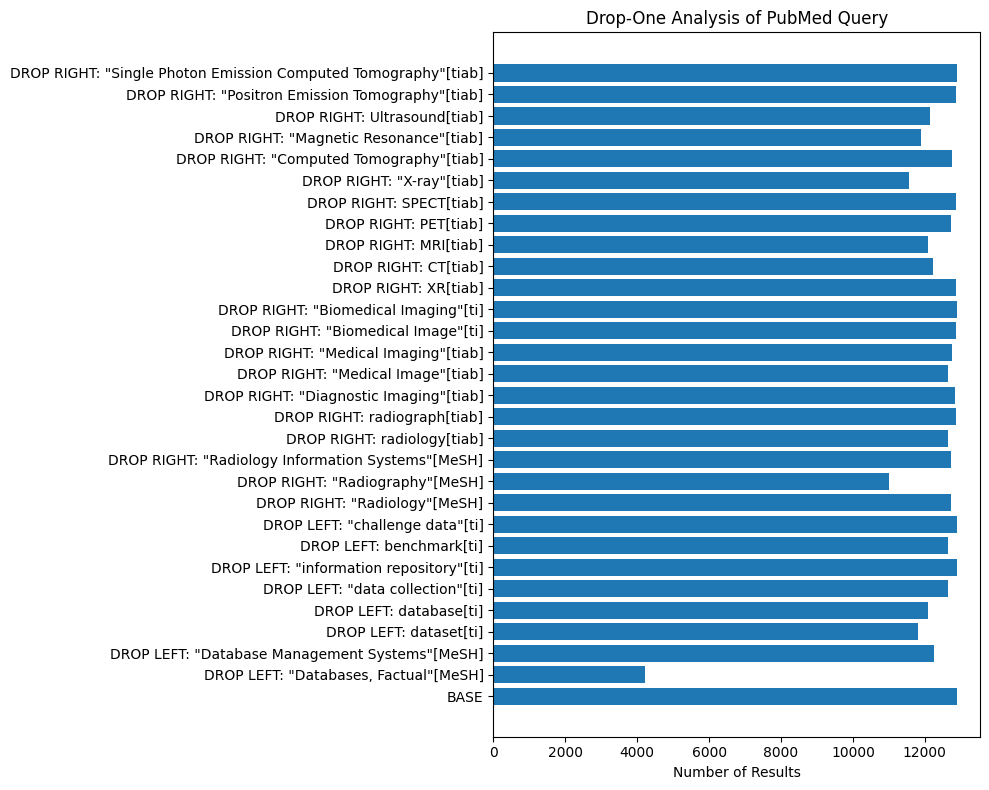

In [5]:
make_bar_plot(results)

### "Databases, Factual"[MeSH] alone introduces a lot of hits (12889 --> 4224). Let's drop it and retry.

In [6]:
PUBMED_QUERY = PUBMED_QUERY.replace('"Databases, Factual"[MeSH] OR ', '')
PUBMED_QUERY

'\n("Database Management Systems"[MeSH] OR dataset[ti] OR database[ti] OR "data collection"[ti] OR "information repository"[ti] OR benchmark[ti] OR "challenge data"[ti])\nAND ("Radiology"[MeSH] OR "Radiography"[MeSH] OR "Radiology Information Systems"[MeSH] OR radiology[tiab] OR radiograph[tiab] OR "Diagnostic Imaging"[tiab] OR "Medical Image"[tiab] OR "Medical Imaging"[tiab] OR "Biomedical Image"[ti] OR "Biomedical Imaging"[ti] OR XR[tiab] OR CT[tiab] OR MRI[tiab] OR PET[tiab] OR SPECT[tiab] OR "X-ray"[tiab] OR "Computed Tomography"[tiab] OR "Magnetic Resonance"[tiab] OR Ultrasound[tiab] OR "Positron Emission Tomography"[tiab] OR "Single Photon Emission Computed Tomography"[tiab])\n'

In [7]:
results = drop_one_analysis(PUBMED_QUERY)
results

[('BASE', 4224),
 ('DROP LEFT: "Database Management Systems"[MeSH]', 3457),
 ('DROP LEFT: dataset[ti]', 2993),
 ('DROP LEFT: database[ti]', 2645),
 ('DROP LEFT: "data collection"[ti]', 3979),
 ('DROP LEFT: "information repository"[ti]', 4223),
 ('DROP LEFT: benchmark[ti]', 3958),
 ('DROP LEFT: "challenge data"[ti]', 4224),
 ('DROP RIGHT: "Radiology"[MeSH]', 4166),
 ('DROP RIGHT: "Radiography"[MeSH]', 3906),
 ('DROP RIGHT: "Radiology Information Systems"[MeSH]', 4083),
 ('DROP RIGHT: radiology[tiab]', 4128),
 ('DROP RIGHT: radiograph[tiab]', 4215),
 ('DROP RIGHT: "Diagnostic Imaging"[tiab]', 4210),
 ('DROP RIGHT: "Medical Image"[tiab]', 4152),
 ('DROP RIGHT: "Medical Imaging"[tiab]', 4166),
 ('DROP RIGHT: "Biomedical Image"[ti]', 4220),
 ('DROP RIGHT: "Biomedical Imaging"[ti]', 4223),
 ('DROP RIGHT: XR[tiab]', 4213),
 ('DROP RIGHT: CT[tiab]', 3975),
 ('DROP RIGHT: MRI[tiab]', 3964),
 ('DROP RIGHT: PET[tiab]', 4157),
 ('DROP RIGHT: SPECT[tiab]', 4203),
 ('DROP RIGHT: "X-ray"[tiab]', 3774

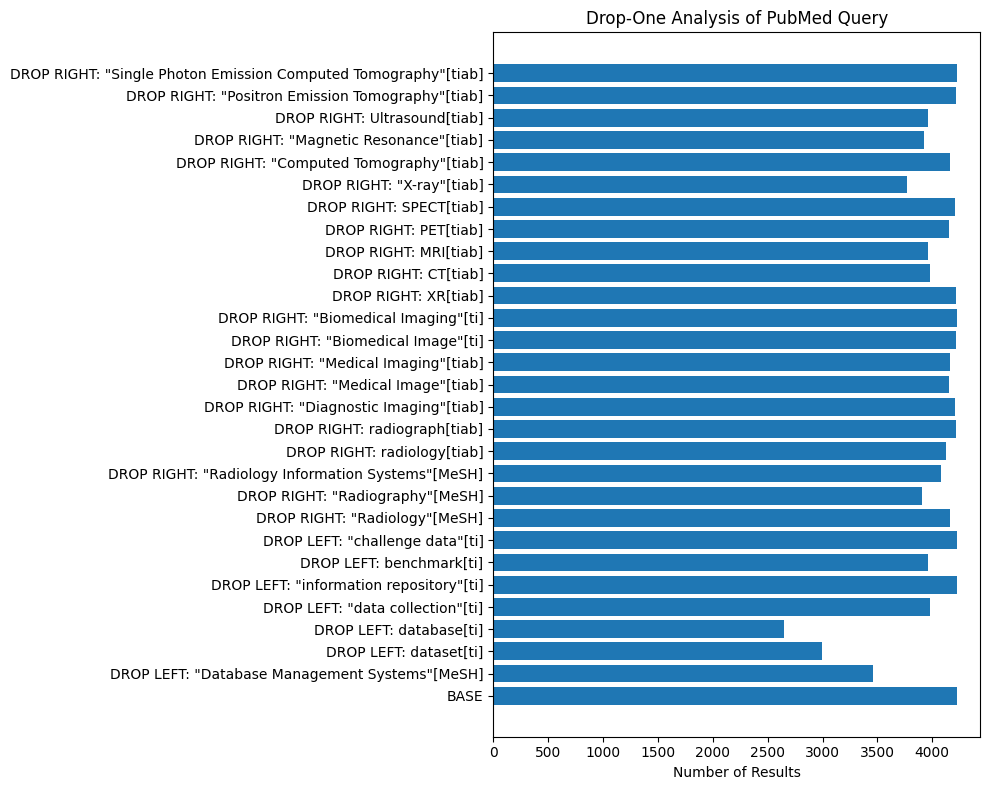

In [8]:
make_bar_plot(results)

### That's better. Let's look at some of the resulting IDs

In [15]:
PUBMED_QUERY = """
("Database Management Systems"[MeSH] OR dataset[ti] OR database[ti] OR "data collection"[ti] OR "information repository"[ti] OR benchmark[ti] OR "challenge data"[ti])
AND ("Radiology"[MeSH] OR "Radiography"[MeSH] OR "Radiology Information Systems"[MeSH] OR radiology[tiab] OR radiograph[tiab] OR "Diagnostic Imaging"[tiab] OR "Medical Image"[tiab] OR "Medical Imaging"[tiab] OR "Biomedical Image"[tiab] OR "Biomedical Imaging"[tiab] OR XR[tiab] OR CT[tiab] OR MRI[tiab] OR PET[tiab] OR SPECT[tiab] OR "X-ray"[tiab] OR "Computed Tomography"[tiab] OR "Magnetic Resonance"[tiab] OR Ultrasound[tiab] OR "Positron Emission Tomography"[tiab] OR "Single Photon Emission Computed Tomography"[tiab])
"""

ids = set(search_pubmed(PUBMED_QUERY))

2026-03-25 01:06:54,809 INFO | Searching PubMed...
2026-03-25 01:06:54,811 DEBUG | PubMed query: 
("Database Management Systems"[MeSH] OR dataset[ti] OR database[ti] OR "data collection"[ti] OR "information repository"[ti] OR benchmark[ti] OR "challenge data"[ti])
AND ("Radiology"[MeSH] OR "Radiography"[MeSH] OR "Radiology Information Systems"[MeSH] OR radiology[tiab] OR radiograph[tiab] OR "Diagnostic Imaging"[tiab] OR "Medical Image"[tiab] OR "Medical Imaging"[tiab] OR "Biomedical Image"[tiab] OR "Biomedical Imaging"[tiab] OR XR[tiab] OR CT[tiab] OR MRI[tiab] OR PET[tiab] OR SPECT[tiab] OR "X-ray"[tiab] OR "Computed Tomography"[tiab] OR "Magnetic Resonance"[tiab] OR Ultrasound[tiab] OR "Positron Emission Tomography"[tiab] OR "Single Photon Emission Computed Tomography"[tiab])

2026-03-25 01:06:55,250 INFO | PubMed search found 4239 articles.


In [10]:
ground_truth_studies = _paper_ground_truth()
for study_key, study_value in ground_truth_studies.items():
    print(f"{study_key}: {study_value['title']}")

radimagenet: RadImageNet: An Open Radiologic Deep Learning Research Dataset for Effective Transfer Learning
mimic_cxr: MIMIC-CXR, a de-identified publicly available database of chest radiographs with free-text reports
uk_biobank: The UK Biobank imaging enhancement of 100,000 participants: rationale, data collection, management and future directions
tcia: The Cancer Imaging Archive (TCIA): Maintaining and Operating a Public Information Repository
merlin: Merlin: a computed tomography vision-language foundation model and dataset
radgenome_chest_ct: Development of a large-scale grounded vision language dataset for chest CT analysis
ct-rate: Generalist foundation models from a multimodal dataset for 3D computed tomography
roco: ROCOv2: Radiology Objects in COntext Version 2, an Updated Multimodal Image Dataset
medmnist_v2: MedMNIST v2: A large-scale lightweight benchmark for 2D and 3D biomedical image classification
kits19: The KiTS19 Challenge Data: 300 Kidney Tumor Cases with Clinical Co

In [16]:
studies_found = set()
for study_key, study_value in ground_truth_studies.items():
    pmid = study_value.get("pmid")
    if pmid is None:
        print(f"Study {study_value['title']} does not have a PMID, skipping...")
        continue
    study_found = pmid in ids
    print(f"Study {study_value['title']} is in PubMed search results:\n{study_found}\n")
    if study_found:
        studies_found.add(study_key)

print(f"Found {len(studies_found)} out of {len(ground_truth_studies)} studies in PubMed search results.")
print(f"Studies found: {studies_found}")
print(f"Studies not found: {set(ground_truth_studies.keys()) - studies_found}")

Study RadImageNet: An Open Radiologic Deep Learning Research Dataset for Effective Transfer Learning is in PubMed search results:
True

Study MIMIC-CXR, a de-identified publicly available database of chest radiographs with free-text reports is in PubMed search results:
True

Study The UK Biobank imaging enhancement of 100,000 participants: rationale, data collection, management and future directions is in PubMed search results:
True

Study The Cancer Imaging Archive (TCIA): Maintaining and Operating a Public Information Repository is in PubMed search results:
True

Study Merlin: a computed tomography vision-language foundation model and dataset is in PubMed search results:
True

Study Development of a large-scale grounded vision language dataset for chest CT analysis is in PubMed search results:
True

Study Generalist foundation models from a multimodal dataset for 3D computed tomography is in PubMed search results:
True

Study ROCOv2: Radiology Objects in COntext Version 2, an Updated

In [12]:
!pip list

Package                                  Version         Build Editable project location
---------------------------------------- --------------- ----- -----------------------------------------------
accelerate                               1.13.0
ag-ui-protocol                           0.1.14
aiofile                                  3.9.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
anthropic                                0.86.0
anyio                                    4.12.1
apache-tvm-ffi                           0.1.9
argcomplete                              3.6.3
astor                                    0.8.1
asttokens                                3.0.1
async-timeout                            5.0.1
attrs                                    26.1.0
Authlib                                  1